<h3>What is the drawback of the RNN Encoder-Decoder approach for machine translation?</h3>

 - RNN encoders are slow, why? because they can't be parallelized, they are computed sequentially, that's a huge comptutational bottleneck for larger models. Also they are not good at storing larger contexts of information. In articles or long translations there may be a word in the begging of the paragraph that's necessary to the conclusion, but RNN based models will easily loose the relationships in this kind of situations.

<h3>What is positional encoding and why is it needed?</h3>

- Positonal encoding is a process of adding positional values (e.g.: sine, cosine squiggles) to the word embeddings. It's needed because the machine has to know if "Alex eats pizza" or "Pizza eats Alex". The positons of the words play a huge role, the word embeddings positions can be changed or mistaken as the words change their posions or come multiples times with different scenarios, there's no way of telling if the word "tree" came earlier than the word "tree" because they have the same embeddings, but adding positional encodings make those "tree" and "tree" unique to each other.

## Imports

In [1]:
import random
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# local module imports
from config import get_config
from train import seq2seq_train
from preperation import LetterTokenizer, CustomDataset, PE_sinusoidal
from modules import generate_name, translate_name, get_names, get_logits, perplexity

from model import (RNNEncoder, 
                RNNDecoder, 
                Seq2SeqTranslator,
                AttentionDecoder,
                Seq2SeqAttention,
                Attention,
                MultiHeadAttention,
                MultiHeadAttnDecoder)

### Setting random seed value for the current environment

In [2]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
seed_everything(RANDOM_STATE) 

In [3]:
# getting some parameter values from config for our models
config = get_config()

lr = config['lr']
seq_len = config['seq_len']
batch_size = config['batch_size']
embedding_dim = config['embedding_dim']
hidden_size = config['hidden_size']
token_to_id = config['token_to_id']
id_to_token = config['id_to_token']
vocab_size = config['vocab_size']

## Data preparation

In [4]:
tokenizer = LetterTokenizer(config, "data/baby_names.csv") 
latin, cyrillic, gender = tokenizer.encode()

In [5]:
print(f"Tokenized values for latin alphabet:")
latin[:3]

Tokenized values for latin alphabet:


[[1, 14, 3, 22, 11, 16, 2, 0, 0, 0, 0, 0, 0],
 [1, 12, 17, 10, 16, 2, 0, 0, 0, 0, 0, 0, 0],
 [1, 25, 11, 14, 14, 11, 3, 15, 2, 0, 0, 0, 0]]

In [6]:
x_train, x_temp, y_train, y_temp = train_test_split(latin, cyrillic, shuffle=True, test_size=0.2, random_state=42)
x_valid, x_test, y_valid, y_test = train_test_split(x_temp, y_temp, shuffle=True, test_size=0.5, random_state=42)

In [7]:
train_dataset = CustomDataset(x_train, y_train)
valid_dataset = CustomDataset(x_valid, y_valid)
test_dataset = CustomDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

## RNN Encoder
1-layer LSTM model to encode the English name.

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [9]:
encoder = RNNEncoder(vocab_size=vocab_size, embedding_dim=embedding_dim, hidden_size=hidden_size, num_layers=1)
loss_fn = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(encoder.parameters(), lr=lr)

loss_hist = seq2seq_train(
    model=encoder, 
    train_dataloader=train_loader, 
    valid_dataloader=valid_loader, 
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device, epochs=10,
    encoder_only=True,
)

Epoch 01:
train_loss: 2.4136 | validation_loss: 2.1995
Epoch 02:
train_loss: 2.1243 | validation_loss: 2.1251
Epoch 03:
train_loss: 2.0448 | validation_loss: 2.0750
Epoch 04:
train_loss: 1.9871 | validation_loss: 2.0461
Epoch 05:
train_loss: 1.9373 | validation_loss: 2.0297
Epoch 06:
train_loss: 1.8918 | validation_loss: 2.0100
Epoch 07:
train_loss: 1.8529 | validation_loss: 1.9895
Epoch 08:
train_loss: 1.8094 | validation_loss: 1.9834
Epoch 09:
train_loss: 1.7731 | validation_loss: 1.9684
Epoch 10:
train_loss: 1.7377 | validation_loss: 1.9648


### c. Generate 10 names using the trained model.

In [10]:
for _ in range(10):
    generate_name(
        model = encoder,
        id_to_token = id_to_token,
        token_to_id = token_to_id,
        temperature=np.random.uniform(0.5, 1.5),
        max_range=random.randrange(4, 14),
        #prefix="al",
        device=device) 

comb
foc
emver
kaniya
kari
pelli
carl
chasil
aura
reticah


## RNN Machine Translation

Implementing LSTM decoder to produce translation.

In [11]:
decoder = RNNDecoder(vocab_size=vocab_size, embedding_dim=embedding_dim, hidden_size=hidden_size, num_layers=1)
seq2seq = Seq2SeqTranslator(encoder=encoder, decoder=decoder, train_encoder=False)

loss_fn = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(seq2seq.parameters(), lr=lr)

seq2seq_loss_hist = seq2seq_train(
    model=seq2seq,
    train_dataloader=train_loader,
    valid_dataloader=valid_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device, epochs=12,
)

Epoch 01:
train_loss: 2.1078 | validation_loss: 1.6996
Epoch 02:
train_loss: 1.4714 | validation_loss: 1.4028
Epoch 03:
train_loss: 1.2351 | validation_loss: 1.2567
Epoch 04:
train_loss: 1.0825 | validation_loss: 1.1400
Epoch 05:
train_loss: 0.9566 | validation_loss: 1.0819
Epoch 06:
train_loss: 0.8610 | validation_loss: 0.9759
Epoch 07:
train_loss: 0.7803 | validation_loss: 0.9230
Epoch 08:
train_loss: 0.7126 | validation_loss: 0.9195
Epoch 09:
train_loss: 0.6532 | validation_loss: 0.8331
Epoch 10:
train_loss: 0.5977 | validation_loss: 0.8441
Epoch 11:
train_loss: 0.5533 | validation_loss: 0.8430
Epoch 12:
train_loss: 0.5072 | validation_loss: 0.7956


### Evaluation

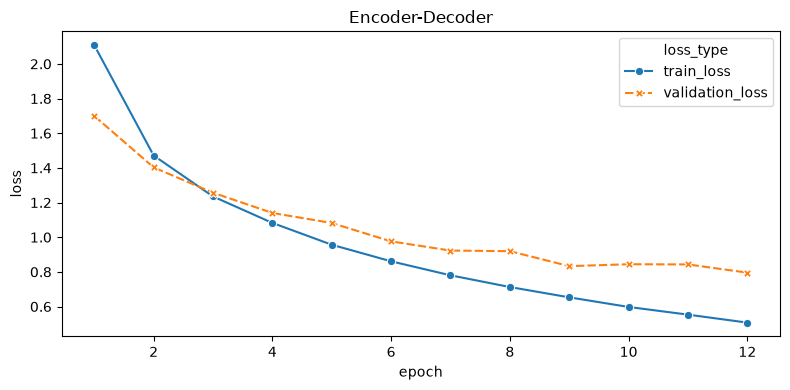

In [12]:
plot_loss = seq2seq_loss_hist.unpivot(on=['train_loss', 'validation_loss'], index="epoch", variable_name="loss_type", value_name="loss")

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(
    plot_loss,
    x="epoch",
    y="loss",
    hue="loss_type",
    markers=True,
    style="loss_type",
    ax=ax,
)
plt.title("Encoder-Decoder")
plt.tight_layout()
plt.show()

### Printing translation for 5 names from train and 5 names from valid parts of dataset.

In [13]:
num = 5
model = seq2seq

# training
translated = []
en_names, ru_names = get_names(train_dataset, num, id_to_token)
for idx in range(num):
    translated.append(translate_name(model, config=config, name=en_names[idx], device=device, max_range=20))
print("Training Dataset:")
print(pl.DataFrame([en_names, ru_names, translated], schema=['english', 'russian', 'translated'], orient="col"))

# validation
translated = []
en_names, ru_names = get_names(valid_dataset, num, id_to_token)
for idx in range(num):
    translated.append(translate_name(model, config=config, name=en_names[idx], device=device, max_range=20))
print("Validation Dataset:")
print(pl.DataFrame([en_names, ru_names, translated], schema=['english', 'russian', 'translated'], orient="col"))

Training Dataset:
shape: (5, 3)
┌─────────┬─────────┬────────────┐
│ english ┆ russian ┆ translated │
│ ---     ┆ ---     ┆ ---        │
│ str     ┆ str     ┆ str        │
╞═════════╪═════════╪════════════╡
│ ambers  ┆ эмберс  ┆ эрсем      │
│ boston  ┆ бостон  ┆ бонт       │
│ elton   ┆ элтон   ┆ элтон      │
│ elinore ┆ элинор  ┆ эллин      │
│ alysa   ┆ алиса   ┆ алиса      │
└─────────┴─────────┴────────────┘
Validation Dataset:
shape: (5, 3)
┌─────────┬─────────┬────────────┐
│ english ┆ russian ┆ translated │
│ ---     ┆ ---     ┆ ---        │
│ str     ┆ str     ┆ str        │
╞═════════╪═════════╪════════════╡
│ erling  ┆ эрлинг  ┆ эрлин      │
│ myra    ┆ майра   ┆ райа       │
│ marc    ┆ марк    ┆ марк       │
│ arthor  ┆ артор   ┆ артор      │
│ devon   ┆ девон   ┆ девон      │
└─────────┴─────────┴────────────┘


<p><h3>They are pretty much realistic, but the model needs a bit more training, I think validation loss ~0.6 would be a good spot. I also noticed if the if the validation loss gets lesser than ~0.8 the translations will start looking more understandable.</h3></p>

### <strong>perplexity score</strong>

In [14]:
# the output of the get_logits() method comes already aligned, so we don't have to realign it.
logits, (x_batch, y_batch) = get_logits(seq2seq, test_loader, device)
seq2seq_perp = perplexity(logits, y_batch)
print(f"Perplexity score: {seq2seq_perp}")

Perplexity score: 1.830254316329956


<h4>When I was testing the perplexity score function earlier, I initialized an untrained model in another kernel, the perplexity score was around 60. And now we can see that the trained model's perplexity score is around 2.00, I can confidentally say the the model has learned its task at least.</h4>

## Attention Machine Translation

In [15]:
attention = Attention(hidden_size=hidden_size)
attn_decoder = AttentionDecoder(
    attention=attention, 
    vocab_size=vocab_size, 
    embedding_dim=embedding_dim, 
    hidden_size=hidden_size, 
    num_layers=1)
seq2seq_attn = Seq2SeqAttention(encoder=encoder, decoder=attn_decoder)


loss_fn = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(seq2seq_attn.parameters(), lr=lr)

attn_loss_hist = seq2seq_train(
    model=seq2seq_attn,
    train_dataloader=train_loader,
    valid_dataloader=valid_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device, epochs=7,
)

Epoch 01:
train_loss: 1.5417 | validation_loss: 0.7367
Epoch 02:
train_loss: 0.5234 | validation_loss: 0.4776
Epoch 03:
train_loss: 0.3560 | validation_loss: 0.3786
Epoch 04:
train_loss: 0.2899 | validation_loss: 0.3610
Epoch 05:
train_loss: 0.2418 | validation_loss: 0.3385
Epoch 06:
train_loss: 0.2113 | validation_loss: 0.3232
Epoch 07:
train_loss: 0.1919 | validation_loss: 0.3140


### Evaluation

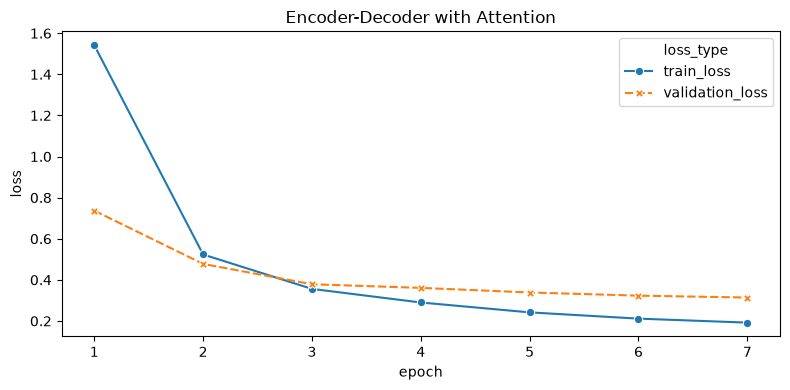

In [16]:
plot_loss = attn_loss_hist.unpivot(on=['train_loss', 'validation_loss'], index="epoch", variable_name="loss_type", value_name="loss")

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(
    plot_loss,
    x="epoch",
    y="loss",
    hue="loss_type",
    markers=True,
    style="loss_type",
    ax=ax,
)
plt.title("Encoder-Decoder with Attention")
plt.tight_layout()
plt.show()

### Printing translation for 5 names from train and 5 names from valid parts of dataset.

In [17]:
num = 5
model = seq2seq_attn

# training
translated = []
en_names, ru_names = get_names(train_dataset, num, id_to_token)
for idx in range(num):
    translated.append(translate_name(model, config=config, name=en_names[idx], device=device, max_range=20, attention=True))
print("Training Dataset:")
print(pl.DataFrame([en_names, ru_names, translated], schema=['english', 'russian', 'translated'], orient="col"))

# validation
translated = []
en_names, ru_names = get_names(valid_dataset, num, id_to_token)
for idx in range(num):
    translated.append(translate_name(model, config=config, name=en_names[idx], device=device, max_range=20, attention=True))
print("Validation Dataset:")
print(pl.DataFrame([en_names, ru_names, translated], schema=['english', 'russian', 'translated'], orient="col"))

Training Dataset:
shape: (5, 3)
┌──────────┬─────────┬────────────┐
│ english  ┆ russian ┆ translated │
│ ---      ┆ ---     ┆ ---        │
│ str      ┆ str     ┆ str        │
╞══════════╪═════════╪════════════╡
│ hosea    ┆ хосеа   ┆ хоза       │
│ coraima  ┆ корайма ┆ корайма    │
│ joni     ┆ джони   ┆ джони      │
│ donald   ┆ дональд ┆ донал      │
│ lashanda ┆ лашанда ┆ лашанда    │
└──────────┴─────────┴────────────┘
Validation Dataset:
shape: (5, 3)
┌───────────┬─────────┬────────────┐
│ english   ┆ russian ┆ translated │
│ ---       ┆ ---     ┆ ---        │
│ str       ┆ str     ┆ str        │
╞═══════════╪═════════╪════════════╡
│ jacquelyn ┆ жаклин  ┆ джеклин    │
│ inga      ┆ инга    ┆ инга       │
│ alicia    ┆ алисия  ┆ алисия     │
│ kelan     ┆ келан   ┆ келан      │
│ destiney  ┆ дестени ┆ дестени    │
└───────────┴─────────┴────────────┘


#### <strong>perplexity score</strong>

In [18]:
logits, (x_batch, y_batch) = get_logits(seq2seq_attn, test_loader, device)
attn_perp = perplexity(logits, y_batch)
print(f"Perplexity score: {attn_perp}")

Perplexity score: 1.1682069301605225


### <strong>comparing the results</strong>

In [19]:
print("Encoder-Decoder Architecture:")
print(f"perplexity score: {seq2seq_perp}")
print(f"average validation loss: {seq2seq_loss_hist.select(pl.col("validation_loss").mean()).item()}")
print("-------------------------------------------")
print("Encoder-Decoder Attention Architecture:")
print(f"perplexity score: {attn_perp}")
print(f"average validation loss: {attn_loss_hist.select(pl.col("validation_loss").mean()).item()}")

Encoder-Decoder Architecture:
perplexity score: 1.830254316329956
average validation loss: 1.059610650169127
-------------------------------------------
Encoder-Decoder Attention Architecture:
perplexity score: 1.1682069301605225
average validation loss: 0.4184985403697212


<h3>My take on the model:</h3>
<p>For the comparison, I'd say Attention architecture is really strong, we can obviously see it by the results just above, the average validation loss of Attention architecture is significantly lower than the average validation loss of a normal Encoder-Decoder architecture. Also Attention model trained on lesser epochs than our Encoder-Decoder model, but the time it takes to train is also noticably slower than Encoder-Decoder model so I guess the time and the number of epochs will cancel out each other. The Preplexity score-(smaller the better) isn't significantly smaller than the Encoder-Decoder model's, but pretty good enough to call it a win. When we take a look at the raw performance by translating real names, it's obvios that the Attention model wins, also, it has a lesser chance of overfitting depending on loss convergence plots.</p>

## Positional Encoding
- Implementing positional encoding using sine and cosine:

In [20]:
pe = PE_sinusoidal(d_model=256, seq_len=seq_len, grad=False) # if grad=True, the weights will be trainable
p_encoder = RNNEncoder(vocab_size=vocab_size, embedding_dim=embedding_dim, hidden_size=hidden_size, num_layers=1, pe=pe) #, pe=pe
loss_fn = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(p_encoder.parameters(), lr=lr)

p_encoder_loss = seq2seq_train(
    model=p_encoder, 
    train_dataloader=train_loader, 
    valid_dataloader=valid_loader, 
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device, epochs=10,
    encoder_only=True,
)

Epoch 01:
train_loss: 2.3956 | validation_loss: 2.2191
Epoch 02:
train_loss: 2.1422 | validation_loss: 2.1283
Epoch 03:
train_loss: 2.0687 | validation_loss: 2.0924
Epoch 04:
train_loss: 2.0146 | validation_loss: 2.0706
Epoch 05:
train_loss: 1.9672 | validation_loss: 2.0463
Epoch 06:
train_loss: 1.9269 | validation_loss: 2.0384
Epoch 07:
train_loss: 1.8900 | validation_loss: 2.0198
Epoch 08:
train_loss: 1.8522 | validation_loss: 1.9964
Epoch 09:
train_loss: 1.8216 | validation_loss: 1.9876
Epoch 10:
train_loss: 1.7872 | validation_loss: 1.9853


I mean there's no changes since there's not any trainable weights. Maybe it got even worse actually, but slightly.

In [21]:
p_decoder = RNNDecoder(vocab_size=vocab_size, embedding_dim=embedding_dim, hidden_size=hidden_size, num_layers=1, pe=pe)
seq2seq = Seq2SeqTranslator(encoder=p_encoder, decoder=p_decoder, train_encoder=False)

loss_fn = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(seq2seq.parameters(), lr=lr)

p_decoder_loss = seq2seq_train(
    model=seq2seq,
    train_dataloader=train_loader,
    valid_dataloader=valid_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device, epochs=12,
)

Epoch 01:
train_loss: 2.2688 | validation_loss: 1.9873
Epoch 02:
train_loss: 1.6361 | validation_loss: 1.5056
Epoch 03:
train_loss: 1.3698 | validation_loss: 1.3358
Epoch 04:
train_loss: 1.2111 | validation_loss: 1.2341
Epoch 05:
train_loss: 1.0951 | validation_loss: 1.1754
Epoch 06:
train_loss: 1.0011 | validation_loss: 1.0783
Epoch 07:
train_loss: 0.9296 | validation_loss: 1.0159
Epoch 08:
train_loss: 0.8646 | validation_loss: 0.9804
Epoch 09:
train_loss: 0.8024 | validation_loss: 0.9702
Epoch 10:
train_loss: 0.7563 | validation_loss: 0.9148
Epoch 11:
train_loss: 0.7127 | validation_loss: 0.9297
Epoch 12:
train_loss: 0.6715 | validation_loss: 0.8809


In [22]:
attention = Attention(hidden_size=hidden_size)
p_attn_decoder = AttentionDecoder(
    attention=attention, 
    vocab_size=vocab_size, 
    embedding_dim=embedding_dim, 
    hidden_size=hidden_size, 
    num_layers=1,
    pe=pe)

seq2seq_attn = Seq2SeqAttention(encoder=p_encoder, decoder=p_attn_decoder)


loss_fn = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(seq2seq_attn.parameters(), lr=lr)

p_attn_decoder_loss = seq2seq_train(
    model=seq2seq_attn,
    train_dataloader=train_loader,
    valid_dataloader=valid_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device, epochs=7,
)

Epoch 01:
train_loss: 1.8434 | validation_loss: 1.0294
Epoch 02:
train_loss: 0.6920 | validation_loss: 0.5609
Epoch 03:
train_loss: 0.4319 | validation_loss: 0.4203
Epoch 04:
train_loss: 0.3360 | validation_loss: 0.3729
Epoch 05:
train_loss: 0.2820 | validation_loss: 0.3640
Epoch 06:
train_loss: 0.2494 | validation_loss: 0.3500
Epoch 07:
train_loss: 0.2129 | validation_loss: 0.3170


<h3>Evaluating the models and comparing results.</h3>

In [23]:
logits, (x_batch, y_batch) = get_logits(seq2seq, test_loader, device)
p_decoder_perp = perplexity(logits, y_batch)
logits, (x_batch, y_batch) = get_logits(seq2seq_attn, test_loader, device)
p_attn_perp = perplexity(logits, y_batch)

print("Without Positonal Encoding\n")
print("Encoder-Decoder Architecture:")
print(f"perplexity score: {seq2seq_perp}")
print(f"average validation loss: {seq2seq_loss_hist.select(pl.col("validation_loss").mean()).item()}")
print("-------------------------------------------")
print("Encoder-Decoder Attention Architecture:")
print(f"perplexity score: {attn_perp}")
print(f"average validation loss: {attn_loss_hist.select(pl.col("validation_loss").mean()).item()}")
print("\n#############################################")
print("With Positional Encoding\n")
print("Encoder-Decoder Architecture:")
print(f"perplexity score: {p_decoder_perp}")
print(f"average validation loss: {p_decoder_loss.select(pl.col("validation_loss").mean()).item()}")
print("-------------------------------------------")
print("Encoder-Decoder Attention Architecture:")
print(f"perplexity score: {p_attn_perp}")
print(f"average validation loss: {p_attn_decoder_loss.select(pl.col("validation_loss").mean()).item()}")

Without Positonal Encoding

Encoder-Decoder Architecture:
perplexity score: 1.830254316329956
average validation loss: 1.059610650169127
-------------------------------------------
Encoder-Decoder Attention Architecture:
perplexity score: 1.1682069301605225
average validation loss: 0.4184985403697212

#############################################
With Positional Encoding

Encoder-Decoder Architecture:
perplexity score: 2.484473943710327
average validation loss: 1.1673745783892546
-------------------------------------------
Encoder-Decoder Attention Architecture:
perplexity score: 1.2641189098358154
average validation loss: 0.4877976731143215


<h3>IT GOT EVEN WORSE!</h3>

<h4>It's because we just introduced 3rd factor without any trainable or associatable parameters(weights), of course it can negatively affect the results.</h4>
- Imagine you're a model and they added some random values to your embeddings and you don't even know what to do with them, because you don't have the power to adjust them (grad=False).
<h4>Now let us see how much our models can improve if we allow them to adjust the positional encoding weights.</h4>

In [24]:
pe = PE_sinusoidal(d_model=256, seq_len=seq_len, grad=True)
p_encoder = RNNEncoder(vocab_size=vocab_size, embedding_dim=embedding_dim, hidden_size=hidden_size, num_layers=1, pe=pe)
loss_fn = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(p_encoder.parameters(), lr=lr)

pe_encoder_loss = seq2seq_train(
    model=p_encoder, 
    train_dataloader=train_loader, 
    valid_dataloader=valid_loader, 
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device, epochs=10,
    encoder_only=True,
)

Epoch 01:
train_loss: 2.4096 | validation_loss: 2.2198
Epoch 02:
train_loss: 2.1437 | validation_loss: 2.1298
Epoch 03:
train_loss: 2.0701 | validation_loss: 2.1036
Epoch 04:
train_loss: 2.0188 | validation_loss: 2.0603
Epoch 05:
train_loss: 1.9718 | validation_loss: 2.0343
Epoch 06:
train_loss: 1.9339 | validation_loss: 2.0240
Epoch 07:
train_loss: 1.8929 | validation_loss: 2.0026
Epoch 08:
train_loss: 1.8625 | validation_loss: 2.0045
Epoch 09:
train_loss: 1.8267 | validation_loss: 1.9860
Epoch 10:
train_loss: 1.7955 | validation_loss: 1.9941


In [25]:
p_decoder = RNNDecoder(vocab_size=vocab_size, embedding_dim=embedding_dim, hidden_size=hidden_size, num_layers=1, pe=pe)
seq2seq = Seq2SeqTranslator(encoder=p_encoder, decoder=p_decoder, train_encoder=False)

loss_fn = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(seq2seq.parameters(), lr=lr)

pe_decoder_loss = seq2seq_train(
    model=seq2seq,
    train_dataloader=train_loader,
    valid_dataloader=valid_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device, epochs=12,
)

Epoch 01:
train_loss: 2.2223 | validation_loss: 1.8282
Epoch 02:
train_loss: 1.6204 | validation_loss: 1.5081
Epoch 03:
train_loss: 1.3803 | validation_loss: 1.3581
Epoch 04:
train_loss: 1.2276 | validation_loss: 1.2409
Epoch 05:
train_loss: 1.1072 | validation_loss: 1.1648
Epoch 06:
train_loss: 1.0174 | validation_loss: 1.1287
Epoch 07:
train_loss: 0.9408 | validation_loss: 1.0564
Epoch 08:
train_loss: 0.8783 | validation_loss: 1.0096
Epoch 09:
train_loss: 0.8222 | validation_loss: 0.9827
Epoch 10:
train_loss: 0.7647 | validation_loss: 0.9627
Epoch 11:
train_loss: 0.7262 | validation_loss: 0.9475
Epoch 12:
train_loss: 0.6826 | validation_loss: 0.9360


In [26]:
attention = Attention(hidden_size=hidden_size)
p_attn_decoder = AttentionDecoder(
    attention=attention, 
    vocab_size=vocab_size, 
    embedding_dim=embedding_dim, 
    hidden_size=hidden_size, 
    num_layers=1,
    pe=pe)

seq2seq_attn = Seq2SeqAttention(encoder=p_encoder, decoder=p_attn_decoder)


loss_fn = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(seq2seq_attn.parameters(), lr=lr)

pe_attn_decoder_loss = seq2seq_train(
    model=seq2seq_attn,
    train_dataloader=train_loader,
    valid_dataloader=valid_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device, epochs=7,
)

Epoch 01:
train_loss: 2.0947 | validation_loss: 1.6305
Epoch 02:
train_loss: 1.1256 | validation_loss: 0.7801
Epoch 03:
train_loss: 0.5632 | validation_loss: 0.5057
Epoch 04:
train_loss: 0.4037 | validation_loss: 0.4490
Epoch 05:
train_loss: 0.3242 | validation_loss: 0.3877
Epoch 06:
train_loss: 0.2714 | validation_loss: 0.3427
Epoch 07:
train_loss: 0.2351 | validation_loss: 0.3340


#### Visualize the learned positional encoding 

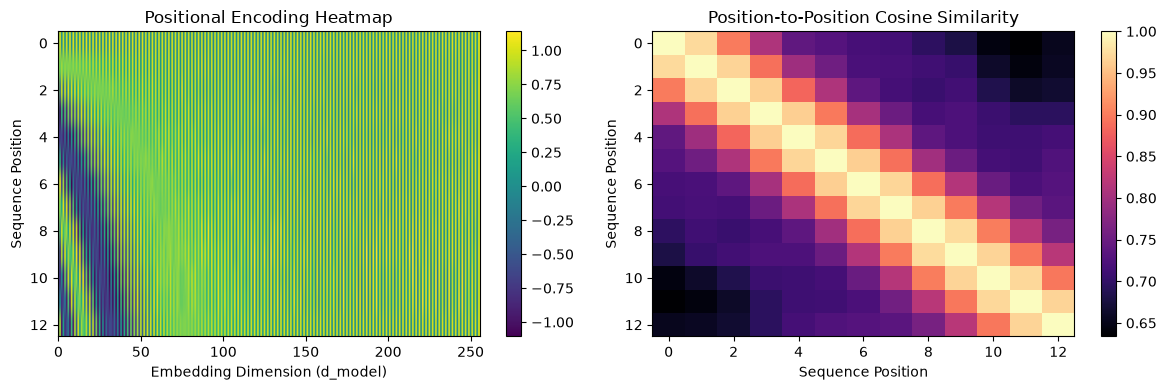

In [27]:
pe_tensor = pe.pe.squeeze(0).detach().cpu()
pe_norm = F.normalize(pe_tensor, p=2, dim=1)
sim_matrix = torch.mm(pe_norm, pe_norm.T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im1 = axes[0].imshow(pe_tensor.numpy(), cmap="viridis", aspect="auto")
axes[0].set_title("Positional Encoding Heatmap")
axes[0].set_xlabel("Embedding Dimension (d_model)")
axes[0].set_ylabel("Sequence Position")
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(sim_matrix.numpy(), cmap="magma", aspect="auto")
axes[1].set_title("Position-to-Position Cosine Similarity")
axes[1].set_xlabel("Sequence Position")
axes[1].set_ylabel("Sequence Position")
fig.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

<h3>Results comparison</h3>

In [28]:
logits, (x_batch, y_batch) = get_logits(seq2seq, test_loader, device)
pe_decoder_perp = perplexity(logits, y_batch)
logits, (x_batch, y_batch) = get_logits(seq2seq_attn, test_loader, device)
pe_attn_perp = perplexity(logits, y_batch)

print("Without Positonal Encoding\n")
print("Encoder-Decoder Architecture:")
print(f"perplexity score: {seq2seq_perp}")
print(f"average validation loss: {seq2seq_loss_hist.select(pl.col("validation_loss").mean()).item()}")
print("-------------------------------------------")
print("Encoder-Decoder Attention Architecture:")
print(f"perplexity score: {attn_perp}")
print(f"average validation loss: {attn_loss_hist.select(pl.col("validation_loss").mean()).item()}")
print("\n#############################################")
print("With Positional Encoding\n")
print("Encoder-Decoder Architecture:")
print(f"perplexity score: {p_decoder_perp}")
print(f"average validation loss: {p_decoder_loss.select(pl.col("validation_loss").mean()).item()}")
print("-------------------------------------------")
print("Encoder-Decoder Attention Architecture:")
print(f"perplexity score: {p_attn_perp}")
print(f"average validation loss: {p_attn_decoder_loss.select(pl.col("validation_loss").mean()).item()}")
print("\n#############################################")
print("With Positional Encoding With Trainable Weights\n")
print("Encoder-Decoder Architecture:")
print(f"perplexity score: {pe_decoder_perp}")
print(f"average validation loss: {pe_decoder_loss.select(pl.col("validation_loss").mean()).item()}")
print("-------------------------------------------")
print("Encoder-Decoder Attention Architecture:")
print(f"perplexity score: {pe_attn_perp}")
print(f"average validation loss: {pe_attn_decoder_loss.select(pl.col("validation_loss").mean()).item()}")

Without Positonal Encoding

Encoder-Decoder Architecture:
perplexity score: 1.830254316329956
average validation loss: 1.059610650169127
-------------------------------------------
Encoder-Decoder Attention Architecture:
perplexity score: 1.1682069301605225
average validation loss: 0.4184985403697212

#############################################
With Positional Encoding

Encoder-Decoder Architecture:
perplexity score: 2.484473943710327
average validation loss: 1.1673745783892546
-------------------------------------------
Encoder-Decoder Attention Architecture:
perplexity score: 1.2641189098358154
average validation loss: 0.4877976731143215

#############################################
With Positional Encoding With Trainable Weights

Encoder-Decoder Architecture:
perplexity score: 2.3000433444976807
average validation loss: 1.1769770056460844
-------------------------------------------
Encoder-Decoder Attention Architecture:
perplexity score: 1.2607487440109253
average validation los

<h3>What are the advantages and disadvantages of using sine and cosine positional encoding instead of trainable weight positional encoding?</h3>

<h4>Actually, from what we observed, adding both trainable and non-trainable sidusoidal parameters to our models didn't do any good, in fact, it even worsened the models' results.</h4>
<br> 
<p>Why though? <br>
Let's remember why we need positional encodings first, we need PE because we wan't the model to have positional awareness in the tokens, which token comes first and which token comes later. But in the RNN architecture models postional encoding doesn't help, becuase the model already processes the tokens by sequence, it's in whatever order they come first, and the positional values will be encoded into the hidden states of the model, so adding positional encoding will only add more parameters to the model to figure out and filter out what is important and what is not. If you look at it, once we enabled the trainable weights the model got even worse results, because now not only the positional encodings but also their parameters context have to be stored inside the hidden weights to filter them out, making the model more prone to waste its parameters on non-relevant context.</p>
    
If so, then why so much fuzz about the positional encodings?

It's because positional encodings are most important in Transformers. Transformers treat the sequence as a bag of words(tokens), everything is mixed up, that's why positional encoding attached to every token will help the model figure out which token came first and which came second. And it's part of the design, that way of treating the sequence is what enables the Transformers to be able to parallelize, to become more efficient, faster and more accurate with the help of positional encodings.

<h4>In conclusion, the positional encodings didn't do any good to our RNN architecture models, but opposite, it resulted in worse performance.</h4>

## Multi-head Attention Machine Translation
Implement Multi-head attention with 3 heads. Why 3? idk.

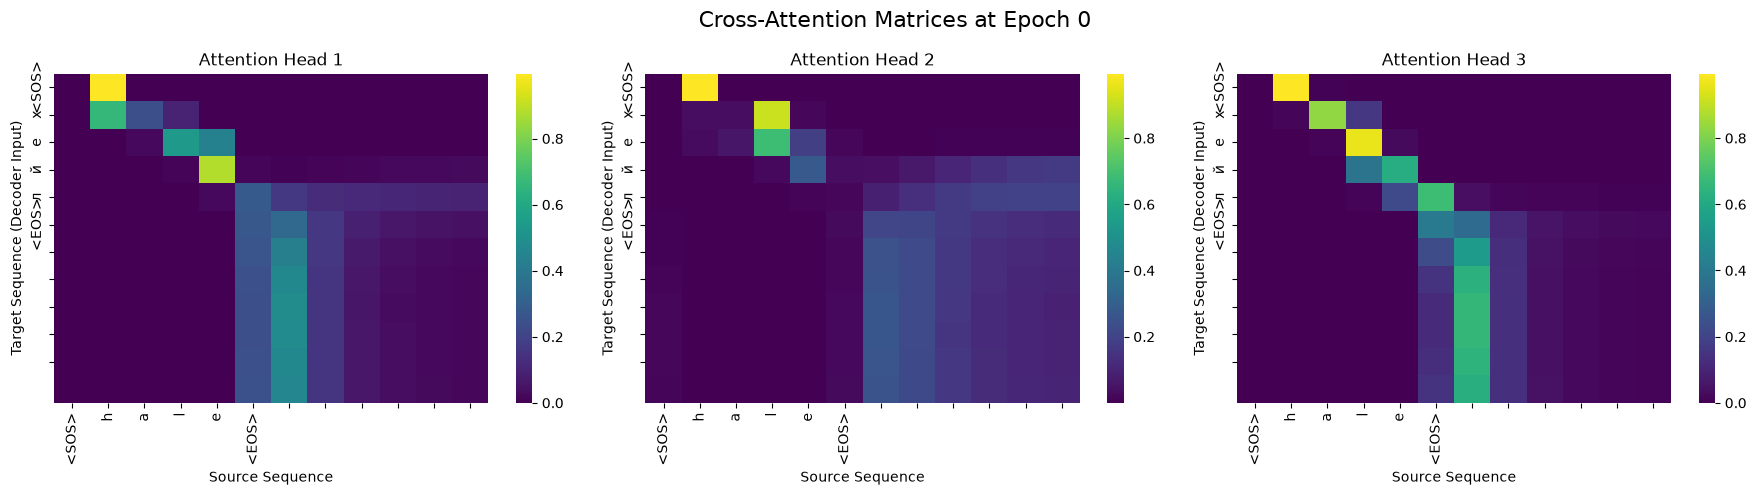

Epoch 01:
train_loss: 1.3095 | validation_loss: 0.5676
Epoch 02:
train_loss: 0.4364 | validation_loss: 0.4221
Epoch 03:
train_loss: 0.3371 | validation_loss: 0.3943


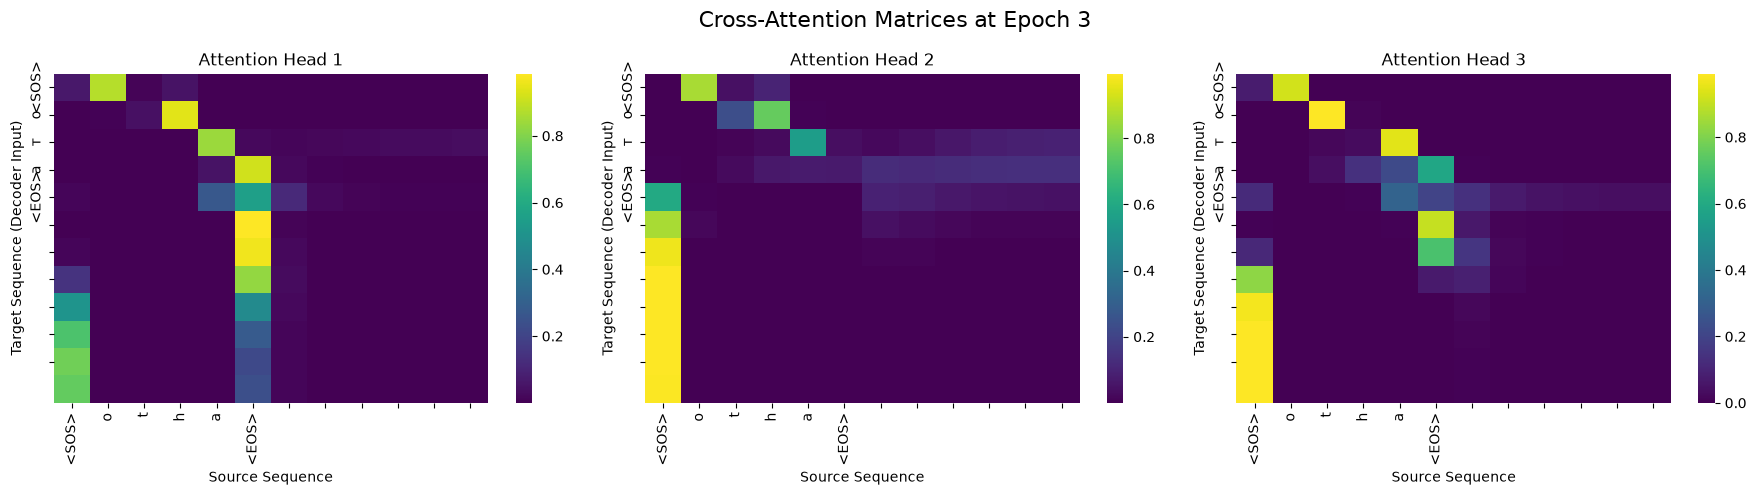

Epoch 04:
train_loss: 0.2876 | validation_loss: 0.3752
Epoch 05:
train_loss: 0.2473 | validation_loss: 0.3345
Epoch 06:
train_loss: 0.2334 | validation_loss: 0.3283


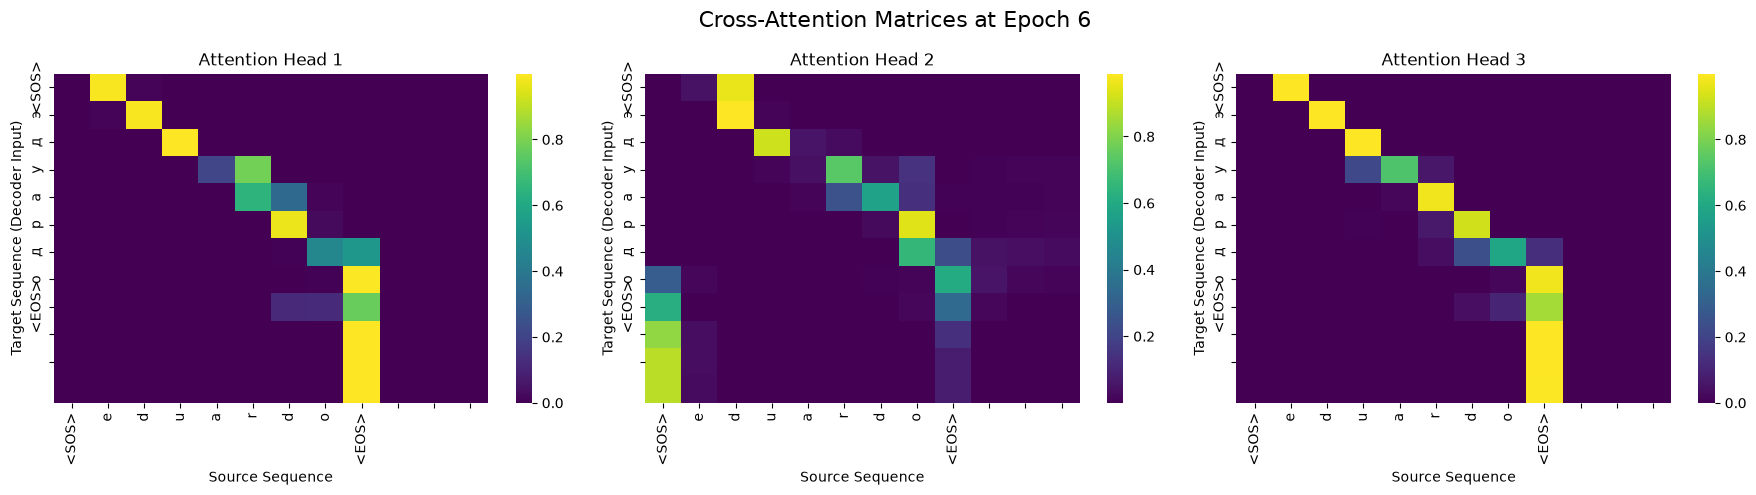

Epoch 07:
train_loss: 0.2117 | validation_loss: 0.3148
Epoch 08:
train_loss: 0.2010 | validation_loss: 0.3808
Epoch 09:
train_loss: 0.1850 | validation_loss: 0.3388


In [29]:
hidden_size = 510
pe_grad = PE_sinusoidal(d_model=hidden_size, seq_len=seq_len, grad=True)
encoder = RNNEncoder(vocab_size=vocab_size, embedding_dim=hidden_size, hidden_size=hidden_size, num_layers=1)
attention = MultiHeadAttention(d_model=hidden_size, n_heads=3)

m_attn_decoder = MultiHeadAttnDecoder(
    attention=attention, 
    vocab_size=vocab_size, 
    embedding_dim=hidden_size, 
    hidden_size=hidden_size, 
    num_layers=1,
    pe=pe_grad)

seq2seq_multi_attn = Seq2SeqAttention(encoder=encoder, decoder=m_attn_decoder, train_encoder=True)


loss_fn = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(seq2seq_multi_attn.parameters(), lr=8e-4)

multi_attn_decoder_loss = seq2seq_train(
    model=seq2seq_multi_attn,
    train_dataloader=train_loader,
    valid_dataloader=valid_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device, epochs=9,
    visualize=True, id_to_token=id_to_token
)

### Evaluation

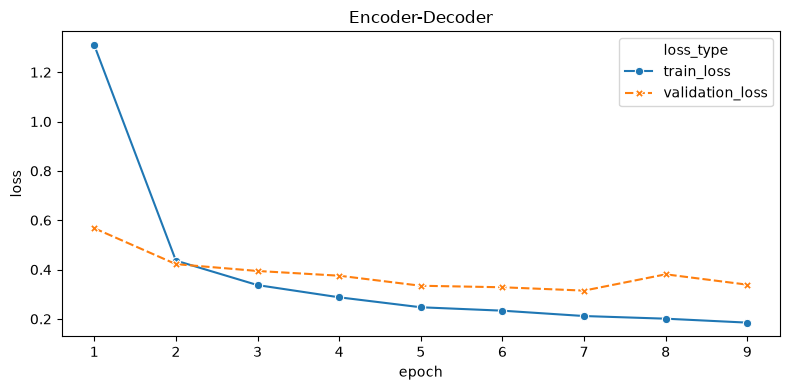

In [30]:
plot_loss = multi_attn_decoder_loss.unpivot(on=['train_loss', 'validation_loss'], index="epoch", variable_name="loss_type", value_name="loss")

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(
    plot_loss,
    x="epoch",
    y="loss",
    hue="loss_type",
    markers=True,
    style="loss_type",
    ax=ax,
)
plt.title("Encoder-Decoder")
plt.tight_layout()
plt.show()

### Print translation for 5 names from train and 5 names from valid part of dataset every n epochs. Are they realistic?

In [31]:
num = 5
model = seq2seq_multi_attn

# training
translated = []
en_names, ru_names = get_names(train_dataset, num, id_to_token)
for idx in range(num):
    translated.append(translate_name(model, config=config, name=en_names[idx], device=device, max_range=20, attention=True))
print("Training Dataset:")
print(pl.DataFrame([en_names, ru_names, translated], schema=['english', 'russian', 'translated'], orient="col"))

# validation
translated = []
en_names, ru_names = get_names(valid_dataset, num, id_to_token)
for idx in range(num):
    translated.append(translate_name(model, config=config, name=en_names[idx], device=device, max_range=20, attention=True))
print("Validation Dataset:")
print(pl.DataFrame([en_names, ru_names, translated], schema=['english', 'russian', 'translated'], orient="col"))

Training Dataset:
shape: (5, 3)
┌────────────┬──────────┬────────────┐
│ english    ┆ russian  ┆ translated │
│ ---        ┆ ---      ┆ ---        │
│ str        ┆ str      ┆ str        │
╞════════════╪══════════╪════════════╡
│ donita     ┆ донита   ┆ донита     │
│ josiephine ┆ жозефина ┆ жозефинайн │
│ cheyanne   ┆ чейэнн   ┆ чейанна    │
│ daryl      ┆ дэрил    ┆ дэрили     │
│ jordin     ┆ джордин  ┆ джордин    │
└────────────┴──────────┴────────────┘
Validation Dataset:
shape: (5, 3)
┌─────────┬─────────┬────────────┐
│ english ┆ russian ┆ translated │
│ ---     ┆ ---     ┆ ---        │
│ str     ┆ str     ┆ str        │
╞═════════╪═════════╪════════════╡
│ ashtyn  ┆ аштын   ┆ эштин      │
│ adolfo  ┆ адольфо ┆ адольфо    │
│ antoine ┆ антуан  ┆ антойна    │
│ primus  ┆ примус  ┆ примус     │
│ darron  ┆ даррон  ┆ даррон     │
└─────────┴─────────┴────────────┘


#### <strong>perplexity score</strong>

In [32]:
# quick check
logits, (x_batch, y_batch) = get_logits(seq2seq_multi_attn, test_loader, device)
multi_attn_perp = perplexity(logits, y_batch)
print(f"perplexity score: {multi_attn_perp}")
print(f"average validation loss: {multi_attn_decoder_loss.select(pl.col("validation_loss").mean()).item()}")

perplexity score: 1.2176597118377686
average validation loss: 0.3840561399819575


<h4>Kinda not significantly good, but not bad either.</h4>

#### and finish:

In [33]:
source_texts = []
target_texts = []
predicted_texts = []

seq2seq_multi_attn.eval()
with torch.no_grad():
    for x_input, y_input in test_loader:
        x_input = x_input.to(device)
        y_input = y_input.to(device)
        
        logits = seq2seq_multi_attn(x_input, y_input)
        pred_ids = logits.argmax(dim=-1)
        
        for i in range(pred_ids.shape[0]):
            src_words = [id_to_token[int(idx)] for idx in x_input[i] if int(idx) not in [0, 1, 2]]
            source_texts.append(" ".join(src_words))
            
            tgt_words = [id_to_token[int(idx)] for idx in y_input[i] if int(idx) not in [0, 1, 2]]
            target_texts.append(" ".join(tgt_words))
            
            pred_words = [id_to_token[int(idx)] for idx in pred_ids[i] if int(idx) not in [0, 1, 2]] 
            predicted_texts.append(" ".join(pred_words))

submission_df = pd.DataFrame({
    'english': source_texts,
    'russian': target_texts,
    'prediction': predicted_texts
})

submission_df.to_csv('data/test_predictions.csv', index=False)
print("saved multi_head_attn_model.pkl and test_predictions.csv, done.")

saved multi_head_attn_model.pkl and test_predictions.csv, done.
